<a href="https://colab.research.google.com/github/Moquiuti/Redes-Neurais-Recorrentes-Deep-Learning-com-PyTorch/blob/main/Analise_de_Sentimentos_GRU_2_Camadas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Sentimentos com GRU de 2 Camadas

Notebook ajustado para o exercício do curso: substituir a GRU de uma camada por uma GRU com duas camadas e passar corretamente a memória interna para a camada linear.

Também foi removida a dependência da API antiga do `torchtext` (`Field`, `LabelField`, `BucketIterator`), que não funciona mais no Colab atual. A preparação dos dados foi reescrita com PyTorch puro.

In [1]:
import os
import re
import tarfile
import random
import urllib.request
from collections import Counter

import numpy as np
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

import matplotlib.pyplot as plt

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## Carregamento do dataset IMDb

O curso usava `torchtext.data.Field` e `datasets.IMDB.splits`, mas essa API antiga foi removida das versões atuais. Para manter o foco no exercício da GRU, o dataset IMDb é baixado diretamente da fonte original e preparado manualmente.

In [2]:
DATA_DIR = "./data"
TAR_PATH = os.path.join(DATA_DIR, "aclImdb_v1.tar.gz")
EXTRACTED_DIR = os.path.join(DATA_DIR, "aclImdb")
URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(EXTRACTED_DIR):
    if not os.path.exists(TAR_PATH):
        print("Baixando dataset IMDb...")
        urllib.request.urlretrieve(URL, TAR_PATH)

    print("Extraindo arquivos...")
    with tarfile.open(TAR_PATH, "r:gz") as tar:
        tar.extractall(DATA_DIR)

print("Dataset pronto.")

Baixando dataset IMDb...
Extraindo arquivos...


/tmp/ipykernel_1230/1951292571.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Dataset pronto.


In [3]:
def carregar_imdb(split):
    exemplos = []

    for label_name, label_id in [("neg", 0), ("pos", 1)]:
        folder = os.path.join(EXTRACTED_DIR, split, label_name)

        for filename in os.listdir(folder):
            if filename.endswith(".txt"):
                path = os.path.join(folder, filename)
                with open(path, "r", encoding="utf-8") as file:
                    texto = file.read()
                exemplos.append((texto, label_id))

    random.shuffle(exemplos)
    return exemplos

train_full = carregar_imdb("train")
test_data = carregar_imdb("test")

valid_size = int(0.2 * len(train_full))
train_size = len(train_full) - valid_size

generator = torch.Generator().manual_seed(SEED)
train_data, valid_data = random_split(train_full, [train_size, valid_size], generator=generator)

print("Treino:", len(train_data))
print("Validação:", len(valid_data))
print("Teste:", len(test_data))

Treino: 20000
Validação: 5000
Teste: 25000


## Tokenização e vocabulário

Aqui eu substituí o papel do antigo `Field`. O texto é quebrado em tokens, depois criei manualmente um vocabulário com os termos mais frequentes.

In [4]:
def tokenizer(texto):
    texto = texto.lower()
    return re.findall(r"\b\w+\b|[^\w\s]", texto)

MAX_VOCAB_SIZE = 25_000
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

contador = Counter()

for texto, label in train_full:
    contador.update(tokenizer(texto))

mais_comuns = contador.most_common(MAX_VOCAB_SIZE - 2)

itos = [PAD_TOKEN, UNK_TOKEN] + [token for token, freq in mais_comuns]
stoi = {token: idx for idx, token in enumerate(itos)}

PAD_IDX = stoi[PAD_TOKEN]
UNK_IDX = stoi[UNK_TOKEN]

print("Tamanho do vocabulário:", len(itos))
print("Primeiros tokens:", itos[:10])

Tamanho do vocabulário: 25000
Primeiros tokens: ['<pad>', '<unk>', 'the', '.', ',', 'and', 'a', 'of', 'to', "'"]


In [5]:
MAX_LEN = 250

def numericalizar(texto):
    tokens = tokenizer(texto)[:MAX_LEN]
    indices = [stoi.get(token, UNK_IDX) for token in tokens]
    return torch.tensor(indices, dtype=torch.long)

class IMDbDataset(Dataset):
    def __init__(self, dados):
        self.dados = list(dados)

    def __len__(self):
        return len(self.dados)

    def __getitem__(self, idx):
        texto, label = self.dados[idx]
        texto_tensor = numericalizar(texto)
        tamanho = len(texto_tensor)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return texto_tensor, tamanho, label_tensor

def collate_batch(batch):
    textos, tamanhos, labels = zip(*batch)

    tamanhos = torch.tensor(tamanhos, dtype=torch.long)
    labels = torch.stack(labels)

    # Ordenação decrescente necessária para pack_padded_sequence com enforce_sorted=True
    tamanhos, indices = tamanhos.sort(descending=True)
    textos = [textos[i] for i in indices]
    labels = labels[indices]

    textos_preenchidos = pad_sequence(textos, padding_value=PAD_IDX)

    return textos_preenchidos, tamanhos, labels

train_dataset = IMDbDataset(train_data)
valid_dataset = IMDbDataset(valid_data)
test_dataset = IMDbDataset(test_data)

BATCH_SIZE = 64

train_iterator = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
valid_iterator = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_iterator = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

for texto, tamanhos, label in valid_iterator:
    print(f"Texto: {texto.shape}, Tamanho: {tamanhos.shape}, Label: {label.shape}")
    print(tamanhos[:10])
    break

Texto: torch.Size([250, 64]), Tamanho: torch.Size([64]), Label: torch.Size([64])
tensor([250, 250, 250, 250, 250, 250, 250, 250, 250, 250])


## Embedding Layer

Como eu removi o `torchtext`, também removi a dependência dos vetores GloVe carregados por `TEXT.vocab.vectors`. A camada de embedding agora é inicializada pelo próprio PyTorch e treinada junto com a rede.

In [6]:
class RNNEmbeddingDemo(nn.Module):

    def __init__(self, tam_vocab, tam_embedding, ind_pad):
        super(RNNEmbeddingDemo, self).__init__()

        self.embedding = nn.Embedding(
            num_embeddings=tam_vocab,
            embedding_dim=tam_embedding,
            padding_idx=ind_pad
        )

    def forward(self, X):
        vectors = self.embedding(X)
        return vectors

tam_vocab = len(itos)
tam_embedding = 100

demo_model = RNNEmbeddingDemo(tam_vocab, tam_embedding, PAD_IDX)

for texto, tamanhos, label in valid_iterator:
    vectors = demo_model(texto)
    print("Entrada:", texto.shape)
    print("Embedding:", vectors.shape)
    break

Entrada: torch.Size([250, 64])
Embedding: torch.Size([250, 64, 100])


## Padding and Packing

O batch contém sequências com tamanhos diferentes. Por isso, usei `pad_sequence` no `DataLoader` e `pack_padded_sequence` dentro do `forward()` da rede.

In [7]:
class RNNPackingDemo(nn.Module):

    def __init__(self, tam_vocab, tam_embedding, ind_pad, hidden_size):
        super(RNNPackingDemo, self).__init__()

        self.embedding = nn.Embedding(tam_vocab, tam_embedding, padding_idx=ind_pad)

        self.hidden_size = hidden_size
        self.rnn = nn.GRU(tam_embedding, hidden_size)

    def forward(self, X, tamanhos):
        print("X:", X.size(), "\n")
        print("tamanhos:", tamanhos[:10], "\n")

        vectors = self.embedding(X)
        print("Vectors:", vectors.size(), "\n")

        hidden = torch.randn(1, X.size(1), self.hidden_size).to(X.device)

        packed_input = pack_padded_sequence(vectors, tamanhos.cpu(), enforce_sorted=True)
        print("Packed input:", packed_input.batch_sizes[:10], "\n")

        packed_output, hidden = self.rnn(packed_input, hidden)
        print("Packed output:", packed_output.batch_sizes[:10], "\n")

        output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output)
        print("output:", output.size(), "\n")

        return output

hidden_size = 256

packing_demo = RNNPackingDemo(tam_vocab, tam_embedding, PAD_IDX, hidden_size).to(device)

for texto, tamanhos, label in valid_iterator:
    texto = texto.to(device)
    saida = packing_demo(texto, tamanhos)
    break

X: torch.Size([250, 64]) 

tamanhos: tensor([250, 250, 250, 250, 250, 250, 250, 250, 250, 250]) 

Vectors: torch.Size([250, 64, 100]) 

Packed input: tensor([64, 64, 64, 64, 64, 64, 64, 64, 64, 64]) 

Packed output: tensor([64, 64, 64, 64, 64, 64, 64, 64, 64, 64]) 

output: torch.Size([250, 64, 256]) 



## Classificando Sequências — exercício da GRU com duas camadas

Aqui está o ponto principal da atividade.

Com uma GRU de uma camada, o `hidden` tinha dimensão `(1, B, F)` e `hidden.squeeze()` funcionava. Com duas camadas, o `hidden` passa a ter dimensão `(2, B, F)`. Portanto, não usei `squeeze()` para alimentar a camada linear. O correto é usar `hidden[-1]`, que seleciona a memória da última camada recorrente e entrega um tensor no formato `(B, F)`.

In [8]:
class RNN(nn.Module):

    def __init__(self, tam_vocab, tam_embedding, ind_pad, hidden_size, output_size):
        super(RNN, self).__init__()

        self.embedding = nn.Embedding(
            num_embeddings=tam_vocab,
            embedding_dim=tam_embedding,
            padding_idx=ind_pad
        )

        self.hidden_size = hidden_size
        self.num_layers = 2

        # Exercício: GRU com duas camadas
        self.rnn = nn.GRU(
            input_size=tam_embedding,
            hidden_size=hidden_size,
            num_layers=self.num_layers
        )

        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, X, tamanhos):
        vectors = self.embedding(X)

        hidden = torch.zeros(
            self.num_layers,
            X.size(1),
            self.hidden_size
        ).to(X.device)

        packed_input = pack_padded_sequence(
            vectors,
            tamanhos.cpu(),
            enforce_sorted=True
        )

        packed_output, hidden = self.rnn(packed_input, hidden)

        # hidden possui dimensão (L, B, F).
        # Como L = 2, usamos hidden[-1] para pegar a memória da última camada.
        # O resultado fica no formato (B, F), compatível com a camada linear.
        output = self.linear(hidden[-1])

        return output

hidden_size = 256
output_size = 2

model = RNN(
    tam_vocab=tam_vocab,
    tam_embedding=tam_embedding,
    ind_pad=PAD_IDX,
    hidden_size=hidden_size,
    output_size=output_size
).to(device)

print(model)

RNN(
  (embedding): Embedding(25000, 100, padding_idx=0)
  (rnn): GRU(100, 256, num_layers=2)
  (linear): Linear(in_features=256, out_features=2, bias=True)
)


In [9]:
for texto, tamanhos, label in valid_iterator:
    texto = texto.to(device)
    label = label.to(device)

    saida = model(texto, tamanhos)

    print("Saída:", saida.shape)
    print("Label:", label.shape)
    break

Saída: torch.Size([64, 2])
Label: torch.Size([64])


## Loss e Otimizador

In [10]:
criterio = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-5)

In [11]:
def forward(iterator, num_samples, etapa):
    if etapa == "Treino":
        model.train()
    else:
        model.eval()

    acuracia = 0.0
    loss_epoca = []

    for texto, tamanhos, rotulo in iterator:
        texto = texto.to(device)
        rotulo = rotulo.to(device)

        with torch.set_grad_enabled(etapa == "Treino"):
            saida = model(texto, tamanhos)

            loss = criterio(saida, rotulo)
            loss_epoca.append(loss.detach().cpu().numpy())

            _, pred = torch.max(saida, axis=-1)
            acuracia += (pred.detach().cpu() == rotulo.detach().cpu()).sum()

            if etapa == "Treino":
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

    loss_epoca = np.asarray(loss_epoca).ravel()
    acuracia = acuracia / float(num_samples)

    print("\n" + "*" * 15 + etapa + "*" * 15)
    print(
        "Loss: {:.4f} +/- {:.4f}, Acurácia: {:.4f}".format(
            loss_epoca.mean(),
            loss_epoca.std(),
            acuracia
        )
    )

    return loss_epoca.mean(), acuracia.item()

## Treinamento

Para testar rapidamente no Colab, deixei `NUM_EPOCHS = 3`.

In [12]:
loss_treino, loss_test = [], []
acc_treino, acc_test = [], []

NUM_EPOCHS = 3

for epoca in range(NUM_EPOCHS):
    print(f"\nÉpoca {epoca + 1}/{NUM_EPOCHS}")

    loss, acuracia = forward(train_iterator, len(train_dataset), "Treino")
    loss_treino.append(loss)
    acc_treino.append(acuracia)

    loss, acuracia = forward(valid_iterator, len(valid_dataset), "Teste")
    loss_test.append(loss)
    acc_test.append(acuracia)


Época 1/3

***************Treino***************
Loss: 0.6791 +/- 0.0226, Acurácia: 0.5563

***************Teste***************
Loss: 0.6481 +/- 0.0395, Acurácia: 0.6188

Época 2/3

***************Treino***************
Loss: 0.6086 +/- 0.0522, Acurácia: 0.6710

***************Teste***************
Loss: 0.6095 +/- 0.0738, Acurácia: 0.6924

Época 3/3

***************Treino***************
Loss: 0.5678 +/- 0.0600, Acurácia: 0.7123

***************Teste***************
Loss: 0.5465 +/- 0.0635, Acurácia: 0.7308


In [13]:
def predict_sentiment(sentence):
    model.eval()

    indices = numericalizar(sentence)
    length_tensor = torch.LongTensor([len(indices)])

    tensor = indices.to(device).unsqueeze(1)

    with torch.no_grad():
        prediction = model(tensor, length_tensor)
        prob = F.softmax(prediction, dim=-1).cpu().data

    return prob

frase = "This movie is very good and exciting"
pred = predict_sentiment(frase)

print(frase)
print("Negativo:", float(pred[0][0]))
print("Positivo:", float(pred[0][1]))

This movie is very good and exciting
Negativo: 0.30939459800720215
Positivo: 0.6906054019927979


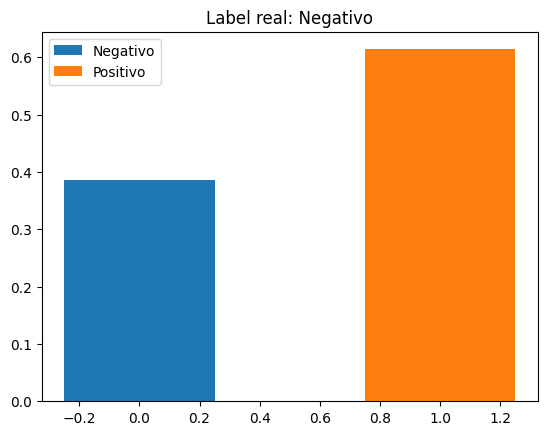

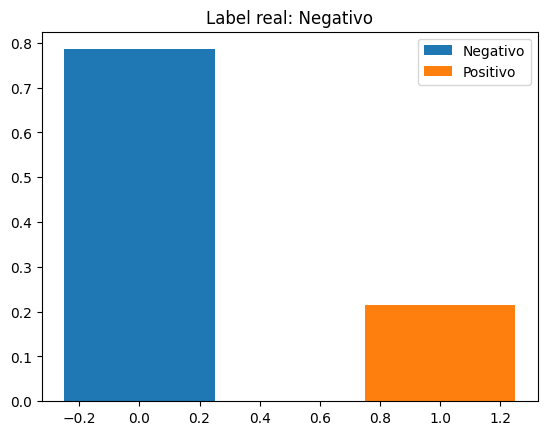

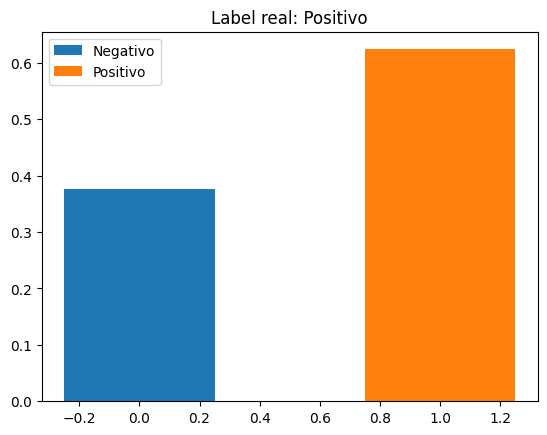

In [14]:
np.random.seed(42)

for i in range(3):
    idx = np.random.choice(len(test_data))
    text, label = test_data[idx]
    pred = predict_sentiment(text)

    plt.bar(0, pred[0][0], label="Negativo", width=0.5)
    plt.bar(1, pred[0][1], label="Positivo", width=0.5)
    plt.title("Label real: " + ("Positivo" if label == 1 else "Negativo"))
    plt.legend()
    plt.show()

## Resumo do ajuste feito

O objetivo inicial do exercício era simples: transformar a GRU em uma GRU com duas camadas e ajustar a passagem da memória interna para a camada linear. A alteração conceitual principal foi trocar o uso de `hidden.squeeze()` por `hidden[-1]`, pois agora a memória da GRU tem dimensão `(2, B, F)`, e precisei usar apenas a memória da última camada.

A atividade ficou mais trabalhosa porque o notebook original dependia de uma API antiga do `torchtext`, que não funciona mais no Colab atual. Por isso, a preparação dos dados foi reescrita com PyTorch puro, mantendo o foco da aula: padding, packing, GRU e classificação de sequências.